# Perturbation workshop

In [1]:
import glob, os, sys, json, jax, jax_obc2, jax_model, optax, scipy
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import jax_amber2 as jaa
import jax.numpy as jnp
import numpy.random as npr
from flax import linen as nn 
from flax.training import train_state 
import mdtraj as md
#import MDAnalysis as mda
import matplotlib as mpl
import matplotlib.pyplot as plt
from decimal import Decimal

import VAE_AE_module3 as j
from sklearn.mixture import GaussianMixture

In [2]:
gas_fun, _, _, _ = j.get_amber_gas_energy_functions('Simulation/ala_deca_peptide.prmtop')

### Initializing the model

In [3]:
# Experiment -> A
A = j.NN_Experiment('modelL_04_2.json')
A.load_model_from_ckpt('modelL/04_latents/rpt_2/model_ckpt_003481.pkl')
A.epoch = 3481     # This seems important. I'll keep it

(8000, 306) (2000, 306)
VAE(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    dropout_rates = [0.3, 0.4, 0.5]
    latents = 4
)
INITIALIZATION COMPLETE


### Auto Encode

In [4]:
# Random Number Generator
rng_init = jax.random.PRNGKey(891)
rng, key = jax.random.split(rng_init)

# AutoEncode
recon = A.state.apply_fn({'params':A.state.params}, A.test_data, rng)

In [5]:
# Verify the shape of the output
recon[0].shape, recon[1].shape

((2000, 306), (2000, 4))

### Apply Gaussian Mixture & visualize data points.

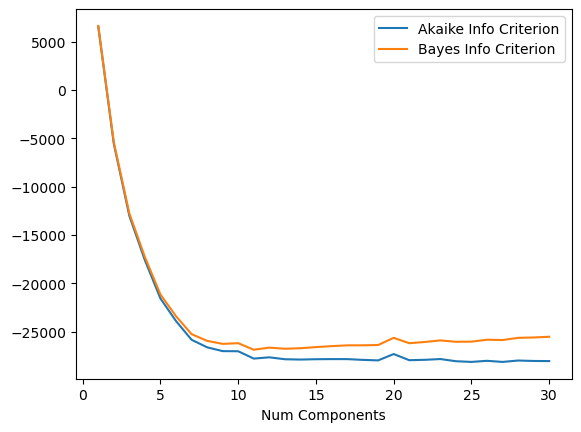

In [6]:
ics = []
for i in range(1, 31):
    X = np.array(recon[1])
    MM = GaussianMixture(n_components=i).fit(X)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')

plt.show()

In [7]:
#choose this based on graph above
n_comp = 12
GMM = GaussianMixture(n_components=n_comp).fit(recon[1])

### Defining the coordinates

Hmmm so you auto encode even before you define the coordinates - 
Yes because the model obtains coordinates during init, and these are coordinates to use in memory right now

In [8]:
# Defining the coordinates
c = md.load('Simulation/decaalanine_1us_split6.dcd', top='Simulation/ala_deca_peptide.prmtop')
# Will this affect the coords variable? 
# This is the process of protein alginment. Yes it effects the coordinates but it is also how the model is trained.
coords = jnp.array(c.superpose(c).xyz)
print(coords.shape)   # Verify the shape of the coordinates

# Seems like I have to flatten the shape to do the perturbation
coords = coords.reshape(coords.shape[0], -1)
print(coords.shape)   # Re-Verify the shape of the coordinates

# rmsd = md.rmsd(c, c)

(10000, 102, 3)
(10000, 306)


### Latents Perturbation
DONE:(TO-DO) Maybe I should add a for loop to perturbate all latents,
for now Let's just edit it here

In [3]:
import latents_perturbator

"""
    Functions list:
        perturb_single_latent(orig_latents, perturb_value=-0.5, perturb_latent=0)
        perturb_all_latents(orig_latents, perturb_values)
        calculate_displacement_vectors(orig_decoded, pert_decoded)
        find_frame_with_max_displacement(displacement_vectors)
        find_frame_with_min_displacement(displacement_vectors)
        plot_mean_displacement(displacement_vectors)
"""

'\n    Functions list:\n        perturb_single_latent(orig_latents, perturb_value=-0.5, perturb_latent=0)\n        perturb_all_latents(orig_latents, perturb_values)\n        calculate_displacement_vectors(orig_decoded, pert_decoded)\n        find_frame_with_max_displacement(displacement_vectors)\n        find_frame_with_min_displacement(displacement_vectors)\n        plot_mean_displacement(displacement_vectors)\n'

In [9]:
# Select only 1 column of Array to perturb to identify data relation

perturb_value = -0.5
perturb_latent = 0
orig_latents = jnp.array(recon[1]) # copy recon[1] to perturbed_latents
pert_latents = orig_latents.at[:, perturb_latent].add(perturb_value) # added perturbed_latents

print(pert_latents.shape == orig_latents.shape) # confirm if the shape is still intact

True


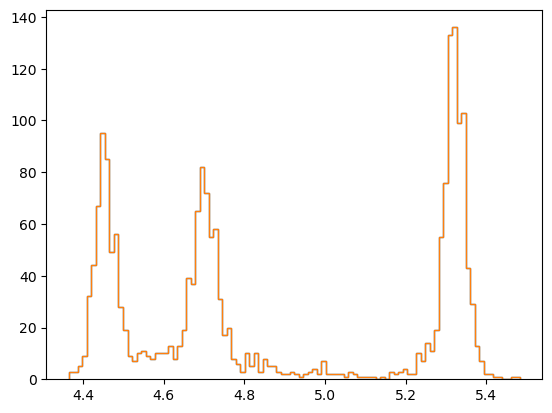

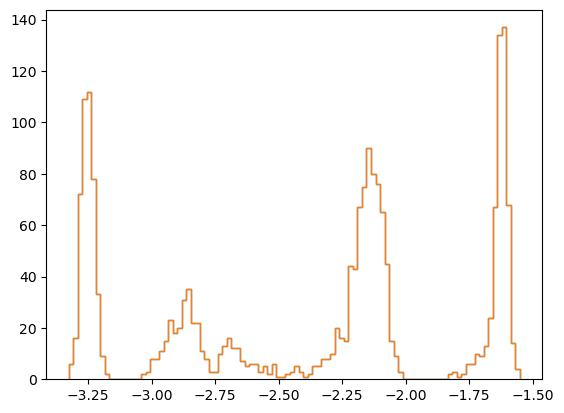

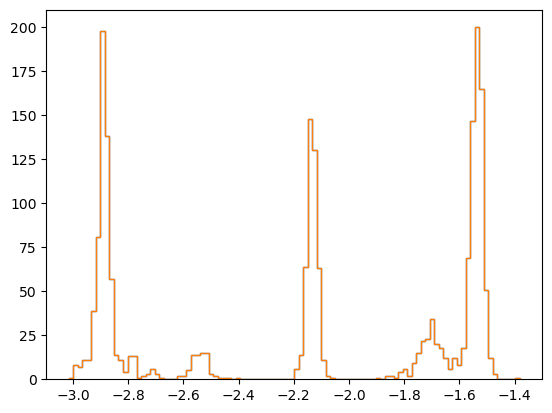

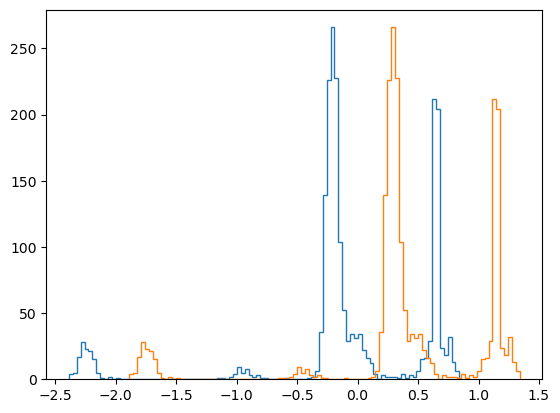

In [10]:
#Plot histograms with original and perturbed latents:
#Notice here that the first is shifted, and the rest are not
for i in range(orig_latents.shape[-1]):
    plt.clf()
    plt.hist(orig_latents[:,i], histtype='step', bins=100)
    plt.hist(pert_latents[:,i], histtype='step', bins=100)
    plt.show()

### Decode perturbed latents

In [11]:
### Perturbed Decoded
# decode the perturbed_latents and print out
orig_decoded = A.model.apply({'params': A.state.params}, orig_latents, rng, method=A.model.decode)
pert_decoded = A.model.apply({'params': A.state.params}, pert_latents, rng, method=A.model.decode)

print(orig_decoded.shape == pert_decoded.shape)

True


### Comparison

In [12]:
motion = orig_decoded - pert_decoded
displacement_vectors = motion.reshape(motion.shape[0], -1, 3)

In [13]:
def find_frame_with_max_displacement(displacement_vectors):
    # Calculate the norm (magnitude of displacement) for each atom in each frame
    norms = np.linalg.norm(displacement_vectors, axis=2)

    # Sum the norms for all atoms to get a total displacement for each frame
    total_displacement_per_frame = norms.sum(axis=1)

    # Find the index of the frame with the maximum total displacement
    frame_with_max_displacement = np.argmax(total_displacement_per_frame)

    # Add 1 to convert the array to the frmae index
    return frame_with_max_displacement+1

def find_frame_with_min_displacement(displacement_vectors):
    # Calculate the norm (magnitude of displacement) for each atom in each frame
    norms = np.linalg.norm(displacement_vectors, axis=2)

    # Sum the norms for all atoms to get a total displacement for each frame
    total_displacement_per_frame = norms.sum(axis=1)

    # Find the index of the frame with the maximum total displacement
    frame_with_max_displacement = np.argmin(total_displacement_per_frame)

    # Add 1 to convert the array to the frmae index
    return frame_with_max_displacement+1

frame_index = find_frame_with_min_displacement(displacement_vectors)

print(f"The frame with the minimum displacement is: {frame_index}")

frame_index = find_frame_with_max_displacement(displacement_vectors)

print(f"The frame with the maximum displacement is: {frame_index}")

The frame with the minimum displacement is: 880
The frame with the maximum displacement is: 267


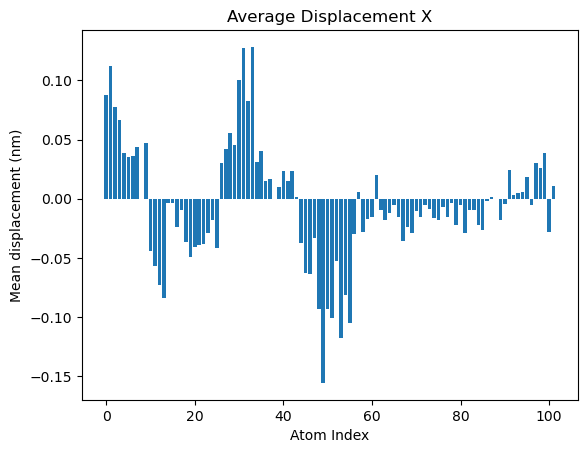

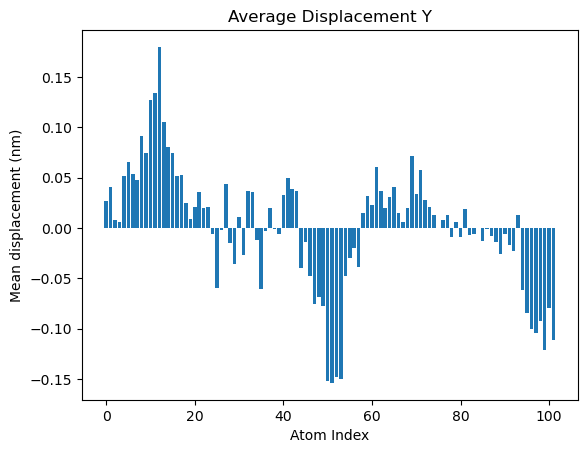

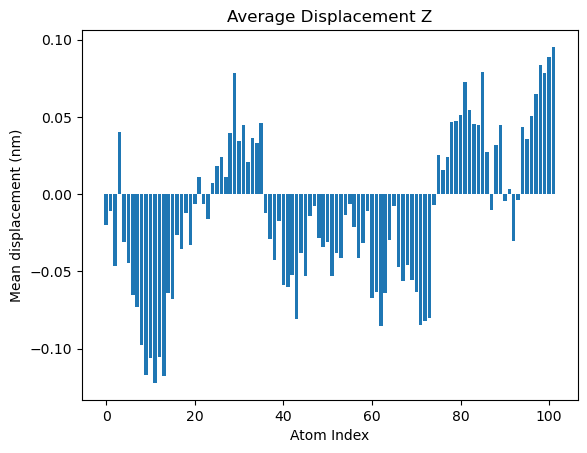

In [14]:
means = np.mean(displacement_vectors, axis=0)
titles = ['Average Displacement X','Average Displacement Y','Average Displacement Z']
for i in range(means.shape[-1]):
    plt.clf()
    plt.bar(np.arange(means.shape[0]), means[:,i])
    plt.title(titles.pop(0))
    plt.ylabel('Mean displacement (nm)')
    plt.xlabel('Atom Index')
    plt.show()

### TO-DO
Find a way to pick frames regarding all the 4 latents perturbed
Calulate and Visualize the relationship between 4 latents

In [15]:
### Verify that decoded items differ

def compare_arrays(arr1, arr2):

    diff_cells = jnp.argwhere(arr1 != arr2)
    
    return diff_cells

diff_cells = compare_arrays(orig_decoded, pert_decoded)
print(f"Different indices: {diff_cells}")

Different indices: [[   0    0]
 [   0    1]
 [   0    2]
 ...
 [1999  303]
 [1999  304]
 [1999  305]]


In [17]:
### writing dcd for original test data -- Redundant. Only needed ONCE. 
#A.write_traj('ORIGINAL', orig_decoded)
# writing dcd for perturbed samples
A.write_traj('PERTURBED_LATENT_'+ str(perturb_latent) + '_subtracted_' + str(perturb_value*-1), pert_decoded)